<a href="https://colab.research.google.com/github/elarchi2005/IA_2025/blob/main/proyecto_kmeans_manhattan_op_ex_ne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clusterización con 3 rasgos (op, ex, ne)
## K-Means Euclidiana + K-Medoids Manhattan

In [2]:
!pip install scikit-learn-extra

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


from sklearn_extra.cluster import KMedoids
plt.rcParams['figure.figsize']=(6,4)
plt.rcParams['figure.dpi']=120

In [4]:
df = pd.read_csv('analisis.csv')
df.head()

,usuario,op,co,ex,ag,ne,wordcount,categoria
0,3gerardpique,34.297953,28.148819,41.948819,29.370315,9.841575,37.0945,7
1,aguerosergiokun,44.986842,20.525865,37.938947,24.279098,10.362406,78.7970,7
2,albertochicote,41.733854,13.745417,38.999896,34.645521,8.836979,49.2604,4
3,AlejandroSanz,40.377154,15.377462,52.337538,31.082154,5.032231,80.4538,2
4,alfredocasero1,36.664677,19.642258,48.530806,31.138871,7.305968,47.0645,4


In [5]:
features=['op','ex','ne']
X=df[features].values
scaler=StandardScaler(); Xs=scaler.fit_transform(X)
Xs[:5]

array([[-1.20499609,  0.16542841,  0.6080745 ],
       [ 0.06816102, -0.39464568,  0.78005819],
       [-0.31930346, -0.2464589 ,  0.27634669],
       [-0.48090044,  1.61646035, -0.98001978],
       [-0.92309481,  1.08475959, -0.2292087 ]])

In [6]:
k_vals=range(2,11)
sil_kmeans=[]
for k in k_vals:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=km.fit_predict(Xs)
    sil_kmeans.append(silhouette_score(Xs,labels))
pd.DataFrame({'k':list(k_vals),'silhouette_kmeans':sil_kmeans})

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x78743a7d3100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


,k,silhouette_kmeans
0,2,0.288270
1,3,0.307106
2,4,0.287966
3,5,0.275859
4,6,0.282065
5,7,0.258760
6,8,0.273950
7,9,0.280656
8,10,0.277248


In [7]:
sil_manh=[]
for k in k_vals:
    km=KMedoids(n_clusters=k,metric='manhattan',random_state=42)
    labels=km.fit_predict(Xs)
    sil_manh.append(silhouette_score(Xs,labels))
pd.DataFrame({'k':list(k_vals),'silhouette_manhattan':sil_manh})

,k,silhouette_manhattan
0,2,0.283352
1,3,0.277002
2,4,0.243157
3,5,0.230595
4,6,0.185128
5,7,0.186851
6,8,0.164382
7,9,0.156726
8,10,0.170520


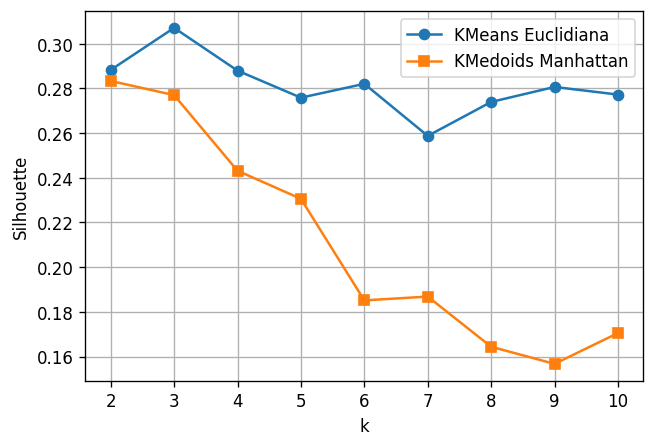

In [8]:
plt.plot(list(k_vals),sil_kmeans,marker='o',label='KMeans Euclidiana')
plt.plot(list(k_vals),sil_manh,marker='s',label='KMedoids Manhattan')
plt.legend(); plt.xlabel('k'); plt.ylabel('Silhouette'); plt.grid(); plt.show()